In [ ]:
What are RNNs?
RNNs are a type of neural network designed to process sequential data by maintaining a hidden state that carries context from previous steps.

Applications:

    Language modeling
    Sentiment analysis
    Time series forecasting
    Music generation
    Machine translation

In [ ]:
The RNN Architecture

    Vanilla RNN Cell:
        Inputs: xt
        Hidden state: ht=tanh⁡(Wxhxt+Whhht−1+b)ht
        Output: yt=Whyht+cyt

In [ ]:
| Term      | Description                                                                                                       |
| --------- | ----------------------------------------------------------------------------------------------------------------- |
| h_t     | The **hidden state at time t** — it stores memory from previous inputs. Think of it as the RNN's internal memory. |
| x_t     | The **input** at time `t`. For example, a word in a sentence or a value in a time series.                         |
| h_{t-1} | The hidden state from the **previous time step** (i.e., time `t-1`).                                              |
| W_{xh}  | The **weight matrix** connecting the input x_t to the hidden state. Learnt during training.                     |
| W_{hh}  | The **recurrent weight matrix** that connects the previous hidden state $h_{t-1}$ to the current hidden state.    |
| b       | The **bias vector**, added to adjust the output (just like in regular neural networks).                           |
| tanh   | The **non-linear activation function**, used to squash values between -1 and 1 and add non-linearity.             |


| Term     | Description                                                                   |
| -------- | ----------------------------------------------------------------------------- |
| y_t    | The **output** at time `t`. Could be a predicted word, class label, or value. |
| W_{hy} | The **output weight matrix**, connecting hidden state to the output.          |
| c      | The **output bias vector**.                                                   |
| h_t    | The **hidden state**, computed earlier.                                       |

This (y_t) gives the output at time t, based on the current hidden state.

In [ ]:
At every time step, the RNN takes in the new input xt and the previous hidden state ht−1, and computes a new hidden state ht. 
This is how it remembers past information.

In [ ]:
Analogy:

Think of an RNN like a person reading a sentence word-by-word:

    ht is their current understanding.
    xt is the word they’re reading now.
    yt is their interpretation based on current understanding.
    The weights W are how they “learn” language over time.

In [ ]:
#Forward Propagation Example (Manual)

In [3]:
import numpy as np

x_seq = [1, 2, 3]
Wxh = np.array([[0.1]])
Whh = np.array([[0.2]])
bh = np.array([0])
h = np.array([0])

for t, x in enumerate(x_seq):
    h = np.tanh(Wxh * x + Whh * h + bh)
    print(f"Step {t}, h = {h}")


Step 0, h = [[0.09966799]]
Step 1, h = [[0.21645477]]
Step 2, h = [[0.33041225]]


Hidden state values: [0.5370495669980352]
Tanh derivatives (1 - h^2): [0.7115777625872229]
Hidden state values: [0.5370495669980352, 0.9332942296597592]
Tanh derivatives (1 - h^2): [0.7115777625872229, 0.12896188088379668]
Hidden state values: [0.5370495669980352, 0.9332942296597592, 0.9898660316763471]
Tanh derivatives (1 - h^2): [0.7115777625872229, 0.12896188088379668, 0.020165239333320928]


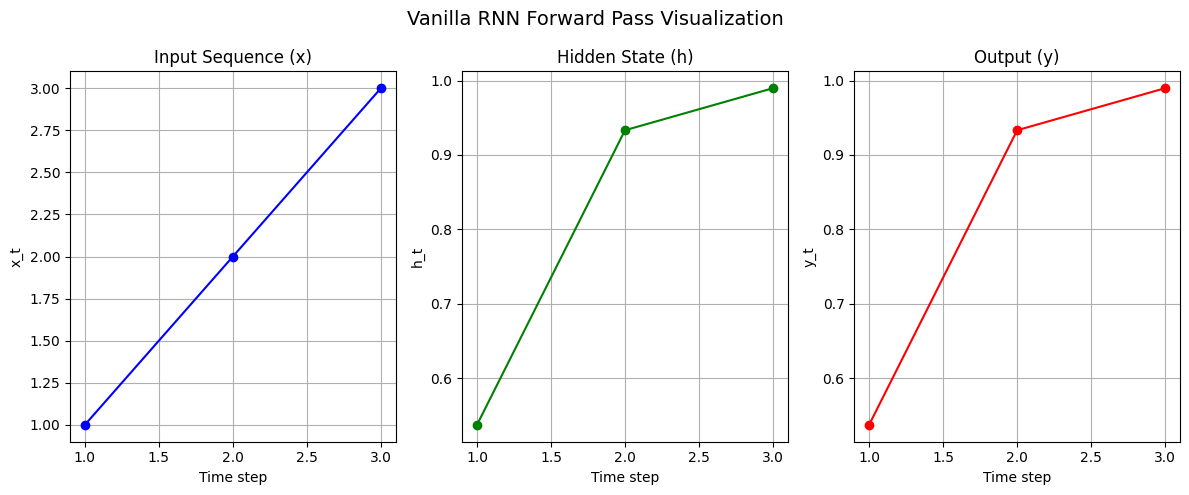

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Activation function: tanh
def tanh(x):
    return np.tanh(x)

# RNN Weights and Hyperparameters
W_xh = 0.6
W_hh = 0.9
W_hy = 1.0
h_0 = 0.0  # initial hidden state

# Input sequence
x_seq = [1, 2, 3]
h_seq = []
y_seq = []

# Forward pass
h_prev = h_0
for x in x_seq:
    z = W_xh * x + W_hh * h_prev
    h_t = tanh(z)
    y_t = W_hy * h_t

    h_seq.append(h_t)
    y_seq.append(y_t)
    h_prev = h_t

    print("Hidden state values:", h_seq)
    print("Tanh derivatives (1 - h^2):", [1 - h**2 for h in h_seq])
    




# Time steps
timesteps = np.arange(1, len(x_seq) + 1)

# Plotting
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.plot(timesteps, x_seq, marker='o', color='blue')
plt.title("Input Sequence (x)")
plt.xlabel("Time step")
plt.ylabel("x_t")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(timesteps, h_seq, marker='o', color='green')
plt.title("Hidden State (h)")
plt.xlabel("Time step")
plt.ylabel("h_t")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(timesteps, y_seq, marker='o', color='red')
plt.title("Output (y)")
plt.xlabel("Time step")
plt.ylabel("y_t")
plt.grid(True)

plt.suptitle("Vanilla RNN Forward Pass Visualization", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
As you can see:

    ht→1
    tanh′(z)=1−h2→0

That’s the saturation effect — even though we can still “see” values changing, 
the model becomes less sensitive to input changes and can’t learn effectively during training.

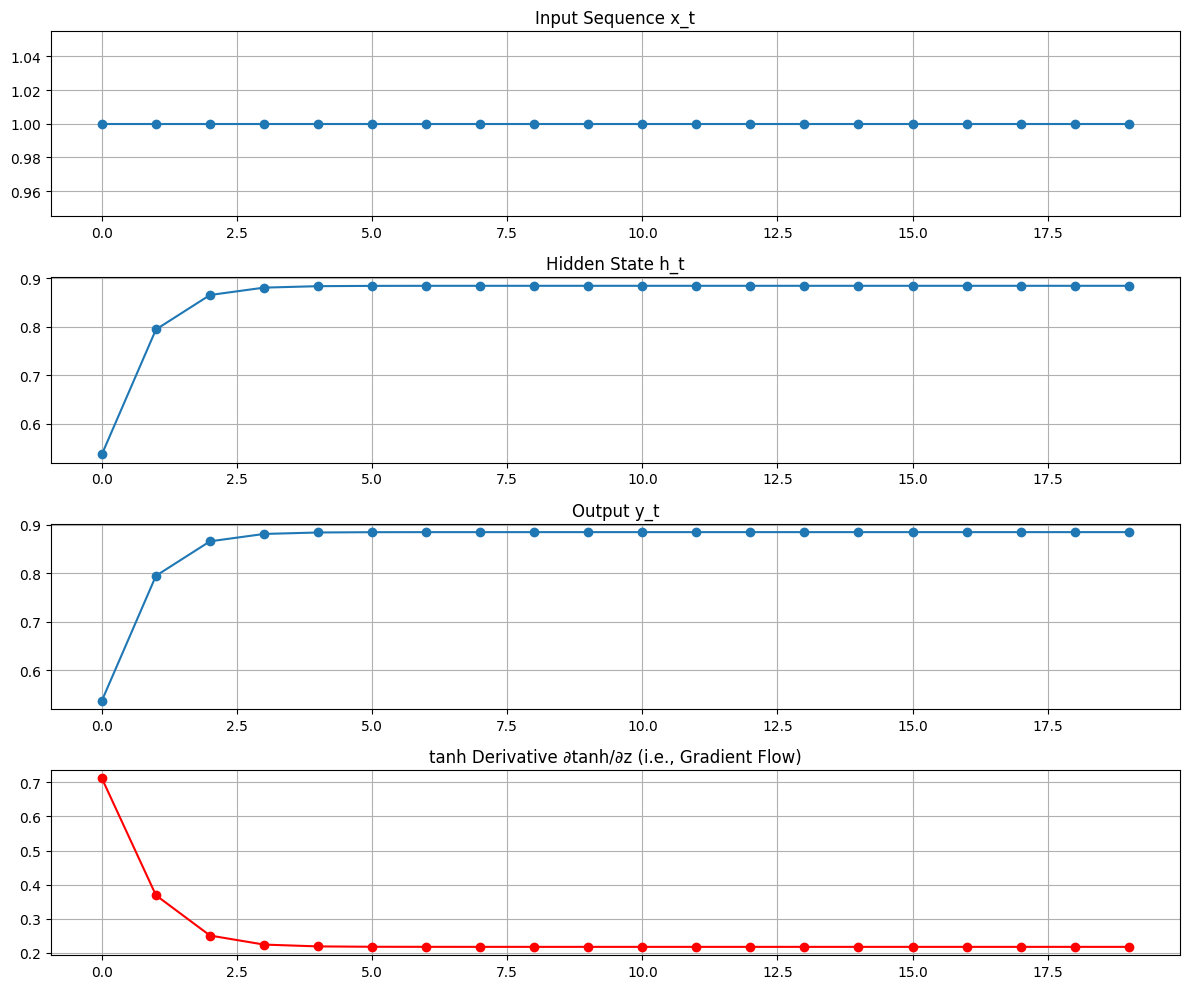

In [8]:
# Saturation if this is the case

import numpy as np
import matplotlib.pyplot as plt

# Longer input sequence of 1s
x_seq = np.ones(20)

# Initialize weights
W_xh = 0.6
W_hh = 0.9
W_hy = 1.0

# Initialize hidden state and outputs
h = 0.0
h_list = []
y_list = []
grad_list = []

# Forward pass over sequence
for x in x_seq:
    h = np.tanh(W_xh * x + W_hh * h)
    y = W_hy * h
    h_list.append(h)
    y_list.append(y)
    grad_list.append(1 - h ** 2)  # Derivative of tanh at current h

# Convert to numpy arrays
x_seq = np.array(x_seq)
h_list = np.array(h_list)
y_list = np.array(y_list)
grad_list = np.array(grad_list)

# Plot all four in subplots
plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
plt.plot(x_seq, marker='o')
plt.title("Input Sequence x_t")
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(h_list, marker='o')
plt.title("Hidden State h_t")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(y_list, marker='o')
plt.title("Output y_t")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(grad_list, marker='o', color='red')
plt.title("tanh Derivative ∂tanh/∂z (i.e., Gradient Flow)")
plt.grid(True)

plt.tight_layout()
plt.show()


In [9]:
# So what if replacce this sigmoid with other activation function 

In [ ]:
| Activation    | Output Range | Derivative Range | Gradient Flow          |
| ------------- | ------------ | ---------------- | ---------------------- |
| **`tanh`**    | \[-1, 1]     | (0, 1], max ≈ 1  | Better than sigmoid    |
| **`sigmoid`** | \[0, 1]      | (0, 0.25]        | Worse (more vanishing) |


Both functions saturate: their gradients approach zero when the input is very high or very low.

But:

    sigmoid always has a derivative < 0.25, even in its steepest part.
    tanh can have derivatives up to 1 near 0 input.

# So using sigmoid instead of tanh would actually make the vanishing gradient problem worse.

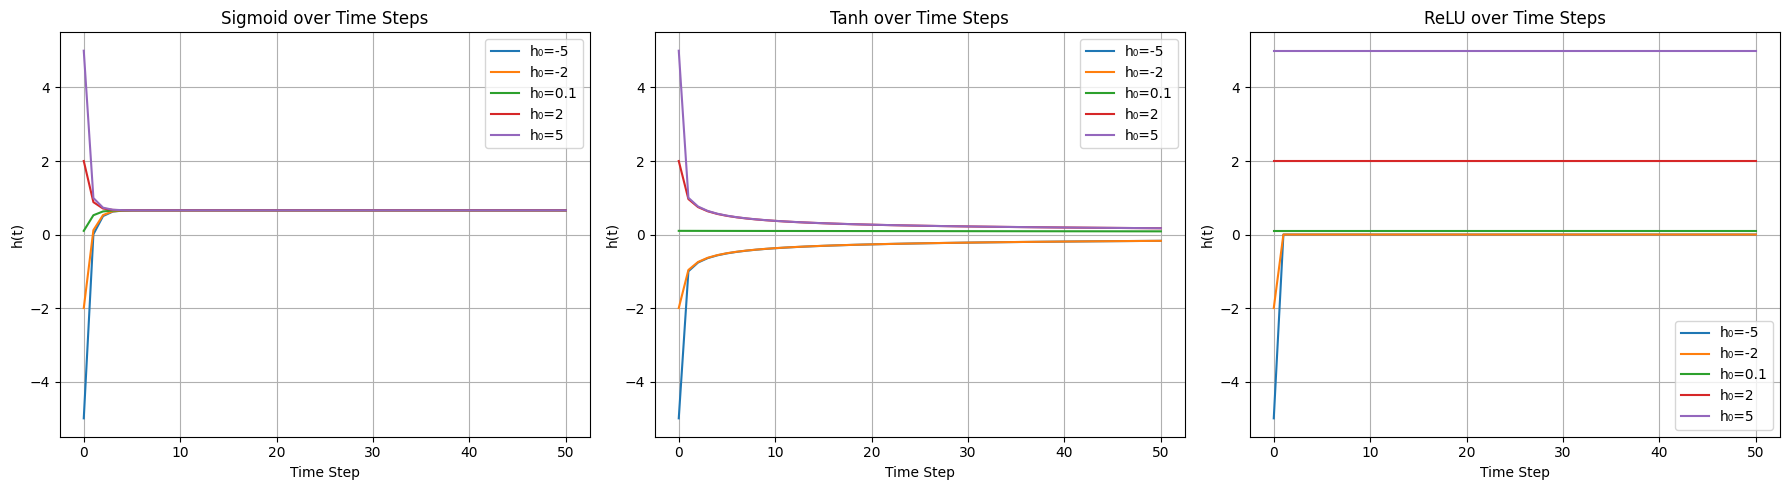

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Activation Functions
def sigmoid(x): return 1 / (1 + np.exp(-x))
def tanh(x): return np.tanh(x)
def relu(x): return np.maximum(0, x)

# Repeatedly apply activation to simulate RNN steps
def simulate_activation(act_func, h0, timesteps):
    h = [h0]
    for t in range(timesteps):
        h_new = act_func(h[-1])
        h.append(h_new)
    return np.array(h)

# Parameters
h0_values = [-5, -2, 0.1, 2, 5]  # Different starting values
timesteps = 50

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
activations = {'Sigmoid': sigmoid, 'Tanh': tanh, 'ReLU': relu}

for i, (name, act_func) in enumerate(activations.items()):
    ax = axs[i]
    for h0 in h0_values:
        h = simulate_activation(act_func, h0, timesteps)
        ax.plot(h, label=f'h₀={h0}')
    ax.set_title(f"{name} over Time Steps")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("h(t)")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
| Activation  | Observation                                                  |
| ----------- | ------------------------------------------------------------ |
| **Sigmoid** | All values converge to \~0.5 (vanishing)                     |
| **Tanh**    | Converge to -1 or +1 (vanishing)                             |
| **ReLU**    | Grows indefinitely if positive (exploding); dead if negative |


In [ ]:
Sigmoid/Tanh: → Gradient vanishes due to saturation in the flat regions.
ReLU: → Explodes for positive values or dies at 0 for negative ones.

This is why vanilla RNNs struggle with long-term memory.

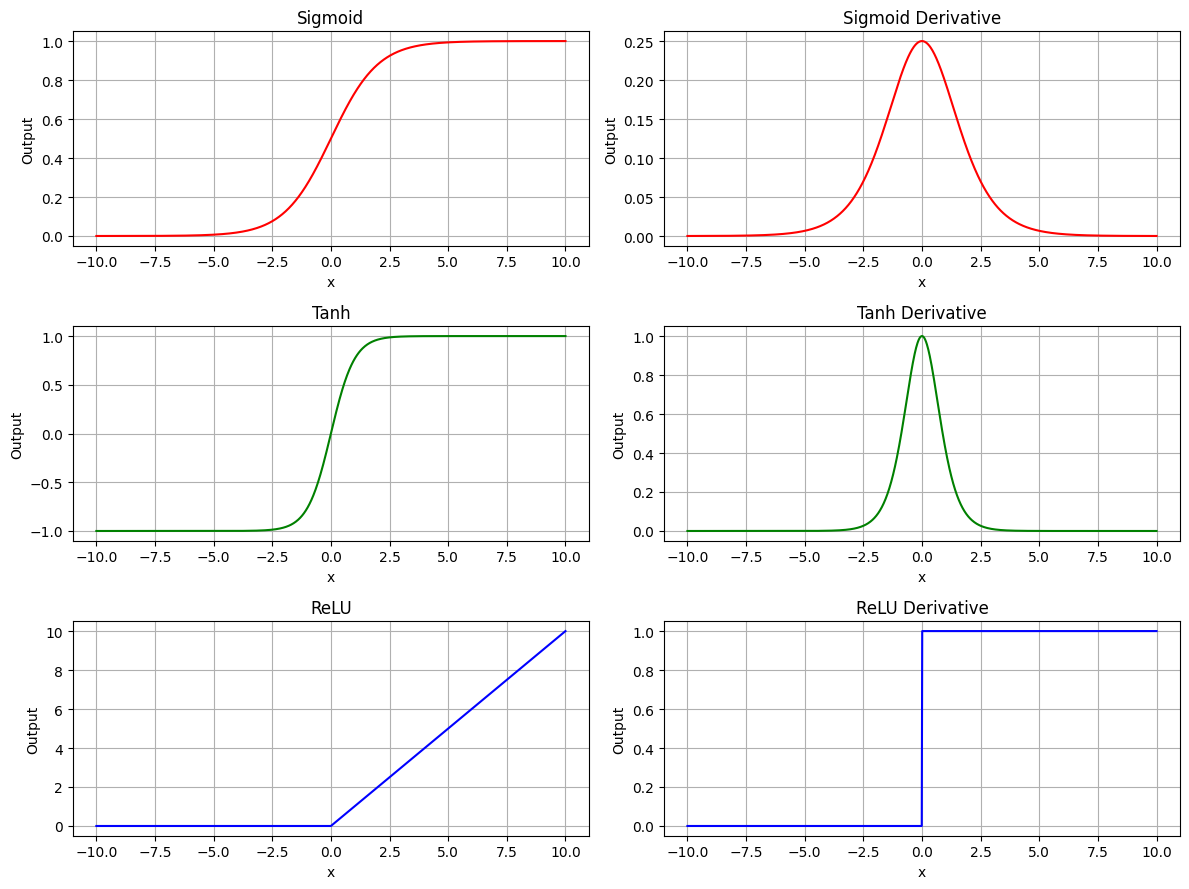

In [12]:
# run this to see the derivatives

# import numpy as np
# import matplotlib.pyplot as plt

# x = np.linspace(-10, 10, 1000)

# # Activation Functions
# sigmoid = 1 / (1 + np.exp(-x))
# tanh = np.tanh(x)
# relu = np.maximum(0, x)

# # Derivatives
# sigmoid_deriv = sigmoid * (1 - sigmoid)
# tanh_deriv = 1 - tanh ** 2
# relu_deriv = np.where(x > 0, 1, 0)

# # Plot all
# fig, axs = plt.subplots(3, 2, figsize=(12, 9))
# axs = axs.flatten()

# axs[0].plot(x, sigmoid, 'r')
# axs[0].set_title("Sigmoid")

# axs[1].plot(x, sigmoid_deriv, 'r')
# axs[1].set_title("Sigmoid Derivative")

# axs[2].plot(x, tanh, 'g')
# axs[2].set_title("Tanh")

# axs[3].plot(x, tanh_deriv, 'g')
# axs[3].set_title("Tanh Derivative")

# axs[4].plot(x, relu, 'b')
# axs[4].set_title("ReLU")

# axs[5].plot(x, relu_deriv, 'b')
# axs[5].set_title("ReLU Derivative")

# for ax in axs:
#     ax.grid(True)
#     ax.set_xlabel("x")
#     ax.set_ylabel("Output")

# plt.tight_layout()
# plt.show()


# RNN suffers -> Vanishing gradients over long sequences <-

In [ ]:
# Vanilla RNNs cannot learn long-term dependencies due to vanishing or exploding gradients.

In [ ]:
Solution: LSTM and GRU

These architectures introduce "gates" to control the flow of information, 
allowing the model to retain relevant long-term context and forget irrelevant parts.
    
Long Short-Term Memory (LSTM):

    Adds a cell state ct (a memory highway) that carries information through time.
    Controlled by gates:
        Forget Gate ft: what to forget
        Input Gate it: what new info to store
        Output Gate ot: what part to send to output

        ft=σ(Wf⋅[ht−1,xt]+bf)
        it=σ(Wi⋅[ht−1,xt]+bi)
        c~t=tanh⁡(Wc⋅[ht−1,xt]+bc)
        ct=ft∗ct−1+it∗c~t
        ot=σ(Wo⋅[ht−1,xt]+bo)
        ht=ot∗tanh⁡(ct)

Key advantage: ct is updated with multiplicative gates, reducing the chance of vanishing gradients.

In [ ]:
Gated Recurrent Unit (GRU):

    A simplified version of LSTM with fewer gates:

        Update Gate zt: how much of the past to keep
        Reset Gate rt: how much of the past to forget

        zt=σ(Wz[ht−1,xt])
        rt=σ(Wr[ht−1,xt])
        h~t=tanh⁡(W[rt∗ht−1,xt])
        ht=(1−zt)∗ht−1+zt∗h~t

GRUs are faster and still retain long-term dependencies better than vanilla RNNs.

In [ ]:
| Model | Problem Solved                | Key Idea            | Complexity |
| ----- | ----------------------------- | ------------------- | ---------- |
| RNN   | Struggles with long memory    | Simple recurrence   | Low        |
| LSTM  | Vanishing/exploding gradients | Memory cell + gates | High       |
| GRU   | Same as LSTM                 | Fewer gates         | Medium     |


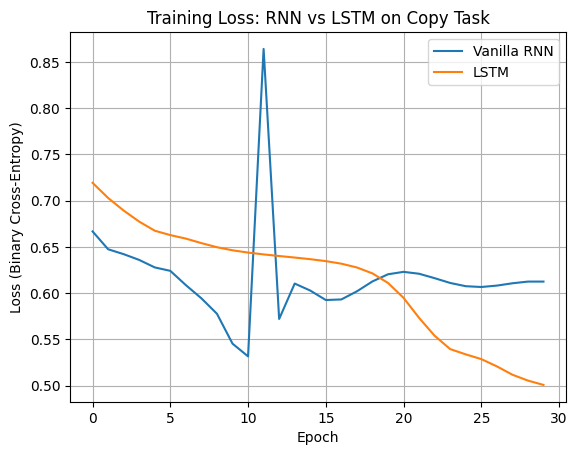

In [13]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Generate data for delayed copy task
def generate_data(seq_len=30, delay=10, batch_size=1000):
    X = np.random.randint(0, 2, (batch_size, seq_len))
    Y = np.zeros_like(X)
    Y[:, delay:] = X[:, :-delay]
    return torch.tensor(X, dtype=torch.float32).unsqueeze(-1), torch.tensor(Y, dtype=torch.float32).unsqueeze(-1)

# RNN
class SimpleRNN(nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()
        self.rnn = nn.RNN(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return torch.sigmoid(self.fc(out))

# LSTM
class SimpleLSTM(nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return torch.sigmoid(self.fc(out))

# Training loop
def train(model, X, Y, epochs=30, lr=0.01):
    loss_fn = nn.BCELoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        opt.zero_grad()
        output = model(X)
        loss = loss_fn(output, Y)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses

# Run everything
X, Y = generate_data(seq_len=30, delay=10)

rnn = SimpleRNN()
lstm = SimpleLSTM()

loss_rnn = train(rnn, X, Y)
loss_lstm = train(lstm, X, Y)

plt.plot(loss_rnn, label='Vanilla RNN')
plt.plot(loss_lstm, label='LSTM')
plt.xlabel("Epoch")
plt.ylabel("Loss (Binary Cross-Entropy)")
plt.title("Training Loss: RNN vs LSTM on Copy Task")
plt.legend()
plt.grid(True)
plt.show()


RNN Final Prediction: -1.1258 vs Target: -1.1258
LSTM Final Prediction: -1.1258 vs Target: -1.1258
GRU Final Prediction: -1.1258 vs Target: -1.1258


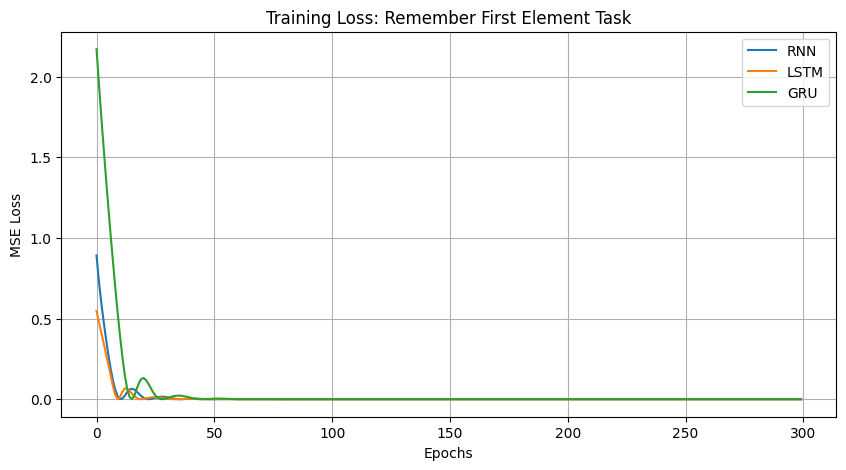

In [15]:
#We are going to train the model and ask
#“After processing the entire 100-step sequence, what do you think the first number was?”


import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Settings
torch.manual_seed(0)
seq_len = 100
batch_size = 1
input_dim = 1
hidden_dim = 10

# Task: Remember the first input value after 100 steps
X = torch.randn(seq_len, batch_size, input_dim)
y = X[0]  # First value in the sequence as target

# Define models
class SimpleRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=False)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[-1])

class SimpleLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=False)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[-1])

class SimpleGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=False)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[-1])

# Training function
def train(model, name):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    losses = []
    for epoch in range(300):
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    print(f"{name} Final Prediction: {out.item():.4f} vs Target: {y.item():.4f}")
    return losses

# Train all
rnn_loss = train(SimpleRNN(), "RNN")
lstm_loss = train(SimpleLSTM(), "LSTM")
gru_loss = train(SimpleGRU(), "GRU")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(rnn_loss, label="RNN")
plt.plot(lstm_loss, label="LSTM")
plt.plot(gru_loss, label="GRU")
plt.title("Training Loss: Remember First Element Task")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
We constructed a synthetic sequence learning task where:

    An input sequence X has 100 time steps.
    The target (y) is simply the first value in that sequence, X[0].
    The model sees the full sequence (from X[0] to X[99]) and is trained to output the first element after the final step.

        This is a memory-based learning task: "Can the model remember what came first?"

In [ ]:
# This happened because you used the same seed (torch.manual_seed(0)) and same input sequence, and
# the models quickly learned to just output the first number since the sequence wasn't changing.

# All models were overfitting to this single fixed example — which is why they all predicted exactly -1.1258, the true value of X[0].

[Batch 20] Losses: RNN: 0.7166 | LSTM: 0.7037 | GRU: 0.7060
[Batch 40] Losses: RNN: 1.1705 | LSTM: 1.1740 | GRU: 1.1709
[Batch 60] Losses: RNN: 0.9535 | LSTM: 0.9622 | GRU: 0.9603
[Batch 80] Losses: RNN: 1.0010 | LSTM: 0.9967 | GRU: 0.9965
[Batch 100] Losses: RNN: 0.8680 | LSTM: 0.8649 | GRU: 0.8665
[Batch 120] Losses: RNN: 0.9716 | LSTM: 0.9702 | GRU: 0.9720
[Batch 140] Losses: RNN: 0.9065 | LSTM: 0.9051 | GRU: 0.9072
[Batch 160] Losses: RNN: 0.9930 | LSTM: 1.0006 | GRU: 1.0006
[Batch 180] Losses: RNN: 1.2445 | LSTM: 1.2478 | GRU: 1.2455
[Batch 200] Losses: RNN: 1.0905 | LSTM: 1.0795 | GRU: 1.0805


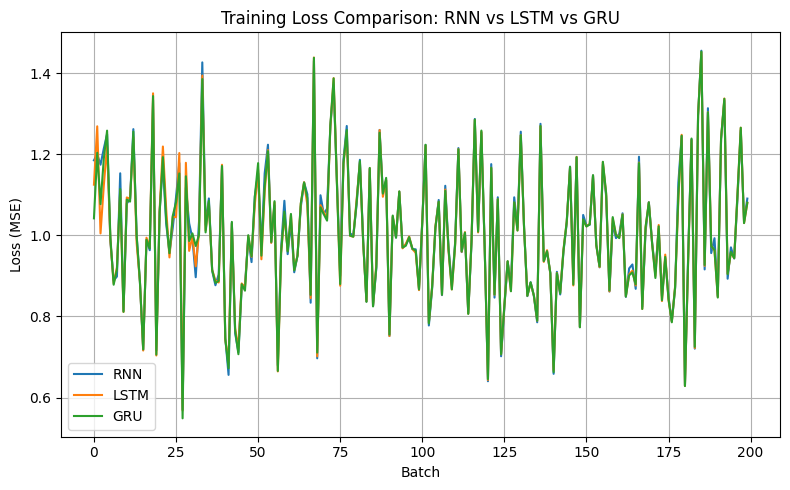

In [16]:
# learning

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Seed and device
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Parameters
seq_len = 100
input_dim = 1
hidden_dim = 32
output_dim = 1
batch_size = 64
num_batches = 200
learning_rate = 0.01

# Model wrapper
class SequenceModel(nn.Module):
    def __init__(self, mode='RNN'):
        super().__init__()
        if mode == 'RNN':
            self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        elif mode == 'LSTM':
            self.rnn = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        elif mode == 'GRU':
            self.rnn = nn.GRU(input_dim, hidden_dim, batch_first=True)
        else:
            raise ValueError("Choose from 'RNN', 'LSTM', or 'GRU'")
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.mode = mode

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])  # Take final hidden state

# Instantiate models
models = {
    'RNN': SequenceModel('RNN').to(device),
    'LSTM': SequenceModel('LSTM').to(device),
    'GRU': SequenceModel('GRU').to(device)
}

# Optimizers and loss
optims = {k: optim.Adam(v.parameters(), lr=learning_rate) for k, v in models.items()}
criterion = nn.MSELoss()

# Store losses
loss_hist = {k: [] for k in models}

# Training loop
for batch in range(num_batches):
    X = torch.randn(batch_size, seq_len, input_dim).to(device)
    y = X[:, 0, :]  # Target: first element

    for name, model in models.items():
        pred = model(X)
        loss = criterion(pred, y)

        optims[name].zero_grad()
        loss.backward()
        optims[name].step()

        loss_hist[name].append(loss.item())

    if (batch + 1) % 20 == 0:
        print(f"[Batch {batch+1}] Losses: " +
              " | ".join([f"{name}: {loss_hist[name][-1]:.4f}" for name in models]))

# Plot loss curves
plt.figure(figsize=(8,5))
for name in models:
    plt.plot(loss_hist[name], label=name)
plt.xlabel("Batch")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss Comparison: RNN vs LSTM vs GRU")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
| Batch | RNN Loss | LSTM Loss | GRU Loss |
| ----- | -------- | --------- | -------- |
| 20    | 0.7166   | 0.7037    | 0.7060   |
| 100   | 0.8680   | 0.8649    | 0.8665   |
| 200   | 1.0905   | 1.0795    | 1.0805   |




All three models are learning, but not improving significantly over time. Loss goes up and down because data is random in each batch.
LSTM and GRU generally perform slightly better than RNN (by ~0.01 in loss), as expected.

But the difference is small here because:

    This task is very hard: predict the first number after seeing 99 random ones.
    There's no temporal dependency or structure to learn from.


Training RNN
Epoch 10 Loss: 0.0000
Epoch 20 Loss: 0.0000
Epoch 30 Loss: 0.0000
Epoch 40 Loss: 0.0000
Epoch 50 Loss: 0.0000

Training LSTM
Epoch 10 Loss: 0.0000
Epoch 20 Loss: 0.0000
Epoch 30 Loss: 0.0000
Epoch 40 Loss: 0.0000
Epoch 50 Loss: 0.0000

Training GRU
Epoch 10 Loss: 0.0000
Epoch 20 Loss: 0.0000
Epoch 30 Loss: 0.0000
Epoch 40 Loss: 0.0000
Epoch 50 Loss: 0.0000


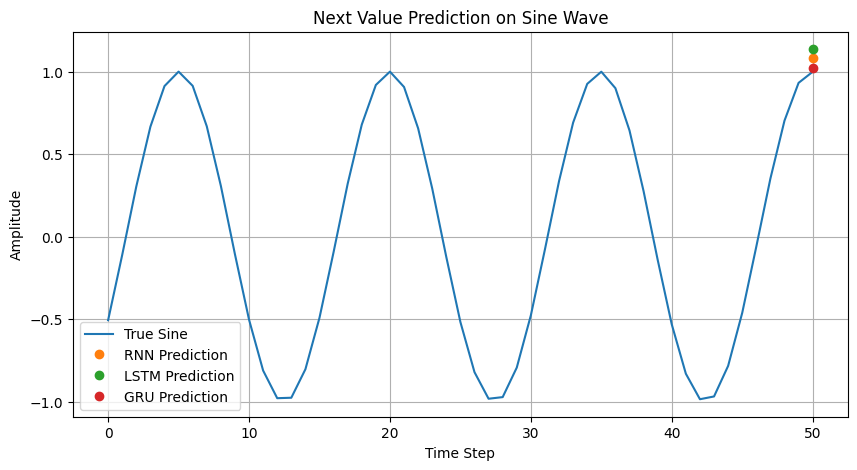

In [17]:
#generating sine waves

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Generate sine wave data
def generate_data(seq_length, num_samples):
    x = np.linspace(0, 100, num_samples)
    data = np.sin(x)
    sequences = []
    targets = []

    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
        targets.append(data[i+seq_length])

    return np.array(sequences), np.array(targets)

# Hyperparameters
SEQ_LEN = 50
BATCH_SIZE = 64
HIDDEN_SIZE = 64
EPOCHS = 50

# Prepare data
X, y = generate_data(SEQ_LEN, 1000)
X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # shape: (N, seq_len, 1)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # shape: (N, 1)

train_dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Define model classes
class RNNModel(nn.Module):
    def __init__(self, cell_type='RNN'):
        super().__init__()
        cell = nn.RNN if cell_type == 'RNN' else nn.LSTM if cell_type == 'LSTM' else nn.GRU
        self.rnn = cell(input_size=1, hidden_size=HIDDEN_SIZE, batch_first=True)
        self.fc = nn.Linear(HIDDEN_SIZE, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])  # use last time step
        return out

# Models
models = {
    'RNN': RNNModel('RNN'),
    'LSTM': RNNModel('LSTM'),
    'GRU': RNNModel('GRU')
}

criterion = nn.MSELoss()

# Training
for name, model in models.items():
    print(f"\nTraining {name}")
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    for epoch in range(EPOCHS):
        total_loss = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1:02d} Loss: {total_loss/len(train_loader):.4f}")

# Evaluation: Predict on last part of sine wave
x_test = np.linspace(100, 120, SEQ_LEN)
y_true = np.sin(np.linspace(100, 121, SEQ_LEN+1))  # for visualization

X_test = torch.tensor(np.sin(x_test).reshape(1, -1, 1), dtype=torch.float32)

plt.figure(figsize=(10, 5))
plt.plot(range(SEQ_LEN+1), y_true, label='True Sine')

for name, model in models.items():
    with torch.no_grad():
        y_pred = model(X_test).item()
        plt.plot(SEQ_LEN, y_pred, 'o', label=f"{name} Prediction")

plt.legend()
plt.title("Next Value Prediction on Sine Wave")
plt.xlabel("Time Step")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


/tmp/ipykernel_1724525/51677441.py:22: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  X_seq = torch.tensor(X_seq, dtype=torch.float32).unsqueeze(-1)  # shape: [samples, seq_len, 1]



Training RNN...
RNN Epoch 0: Loss = 0.5461
RNN Epoch 20: Loss = 0.0051
RNN Epoch 40: Loss = 0.0010
RNN Epoch 60: Loss = 0.0002
RNN Epoch 80: Loss = 0.0001

Training LSTM...
LSTM Epoch 0: Loss = 0.5113
LSTM Epoch 20: Loss = 0.0107
LSTM Epoch 40: Loss = 0.0007
LSTM Epoch 60: Loss = 0.0001
LSTM Epoch 80: Loss = 0.0000

Training GRU...
GRU Epoch 0: Loss = 0.5439
GRU Epoch 20: Loss = 0.0074
GRU Epoch 40: Loss = 0.0003
GRU Epoch 60: Loss = 0.0001
GRU Epoch 80: Loss = 0.0000


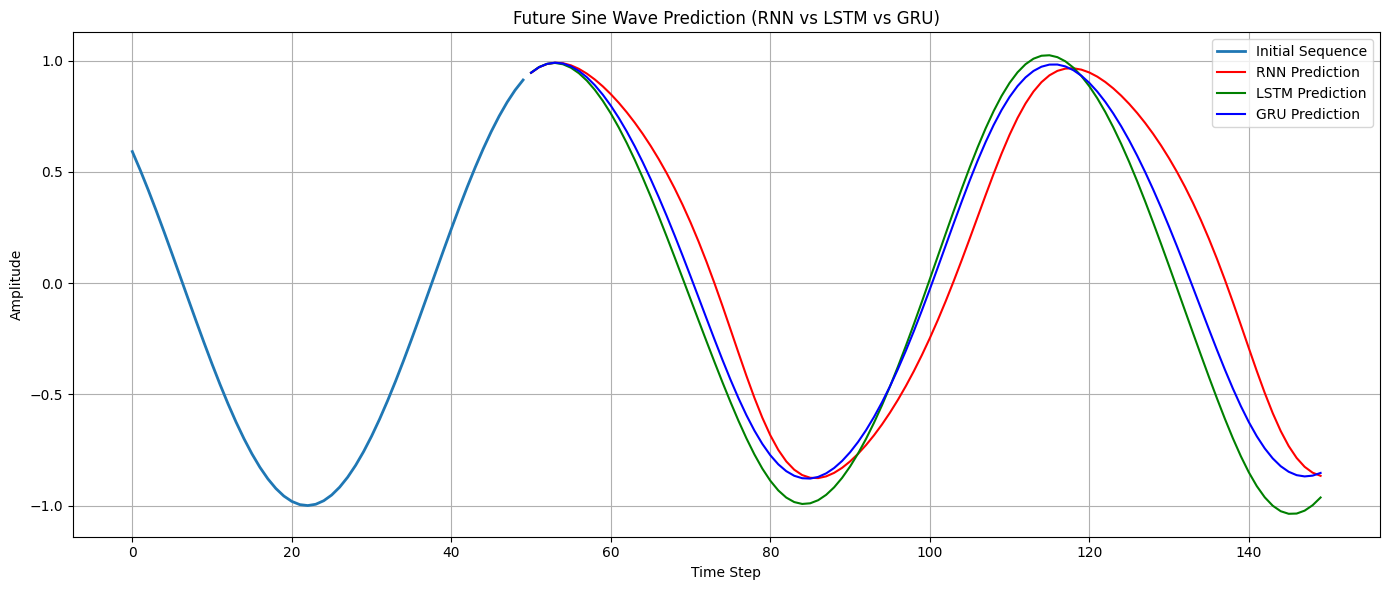

In [18]:
#  generating more sine 

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Parameters
SEQ_LEN = 50
EPOCHS = 100
LR = 0.01
FUTURE_STEPS = 100

# Generate sine wave data
x = np.linspace(0, 20, 200)
y = np.sin(x)

# Prepare training sequences
X_seq, Y_seq = [], []
for i in range(len(y) - SEQ_LEN):
    X_seq.append(y[i:i+SEQ_LEN])
    Y_seq.append(y[i+SEQ_LEN])
X_seq = torch.tensor(X_seq, dtype=torch.float32).unsqueeze(-1)  # shape: [samples, seq_len, 1]
Y_seq = torch.tensor(Y_seq, dtype=torch.float32).unsqueeze(-1)  # shape: [samples, 1]

# Define models
class RNNModel(nn.Module):
    def __init__(self, cell_type='RNN'):
        super().__init__()
        hidden_size = 32
        if cell_type == 'LSTM':
            self.rnn = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
        elif cell_type == 'GRU':
            self.rnn = nn.GRU(input_size=1, hidden_size=hidden_size, batch_first=True)
        else:
            self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.linear(out[:, -1, :])

# Train model
def train_model(model, name):
    optimizer = optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()
    for epoch in range(EPOCHS):
        optimizer.zero_grad()
        pred = model(X_seq)
        loss = loss_fn(pred, Y_seq)
        loss.backward()
        optimizer.step()
        if epoch % 20 == 0:
            print(f"{name} Epoch {epoch}: Loss = {loss.item():.4f}")
    return model

# Generate future sequence
def generate_future(model, init_sequence, steps):
    model.eval()
    generated = list(init_sequence)
    for _ in range(steps):
        inp = torch.tensor(generated[-SEQ_LEN:], dtype=torch.float32).view(1, SEQ_LEN, 1)
        with torch.no_grad():
            pred = model(inp)
        generated.append(pred.item())
    return generated

# Initialize and train models
models = {}
for cell in ['RNN', 'LSTM', 'GRU']:
    print(f"\nTraining {cell}...")
    model = RNNModel(cell_type=cell)
    models[cell] = train_model(model, name=cell)

# Starting point for future generation
start_seq = y[-SEQ_LEN:].tolist()

# Plotting predictions
plt.figure(figsize=(14, 6))
plt.plot(range(SEQ_LEN), start_seq, label='Initial Sequence', linewidth=2)

colors = {'RNN': 'r', 'LSTM': 'g', 'GRU': 'b'}
for name, model in models.items():
    pred = generate_future(model, start_seq, FUTURE_STEPS)
    plt.plot(range(SEQ_LEN, SEQ_LEN + FUTURE_STEPS), pred[SEQ_LEN:], label=f"{name} Prediction", color=colors[name])

plt.title("Future Sine Wave Prediction (RNN vs LSTM vs GRU)")
plt.xlabel("Time Step")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


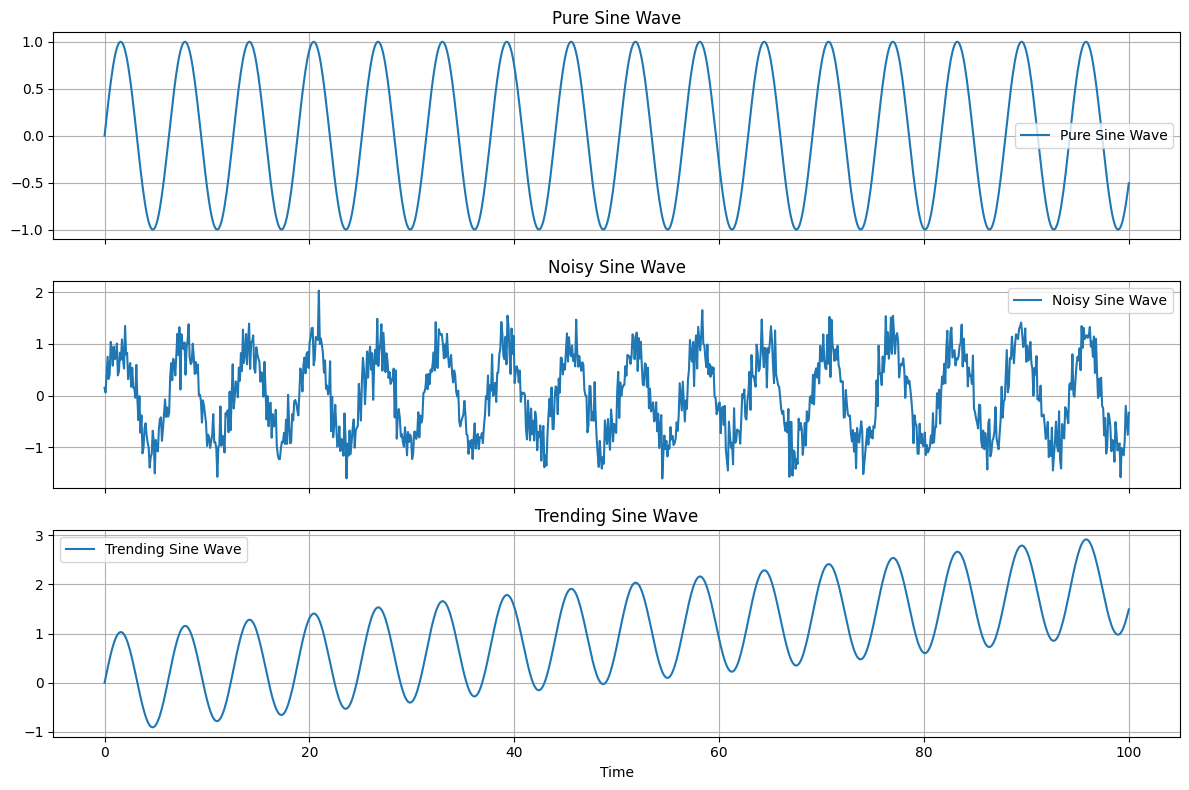

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Generate time steps
np.random.seed(42)
timesteps = np.linspace(0, 100, 1000)

# Define signals
pure_sine = np.sin(timesteps)
noisy_sine = pure_sine + 0.3 * np.random.randn(*timesteps.shape)
trending_sine = np.sin(timesteps) + 0.02 * timesteps

# Combine all series into a dictionary
series_dict = {
    "Pure Sine Wave": pure_sine,
    "Noisy Sine Wave": noisy_sine,
    "Trending Sine Wave": trending_sine
}

# Plot
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for idx, (title, data) in enumerate(series_dict.items()):
    axs[idx].plot(timesteps, data, label=title, color='tab:blue')
    axs[idx].set_title(title)
    axs[idx].legend()
    axs[idx].grid(True)

plt.xlabel("Time")
plt.tight_layout()
plt.show()


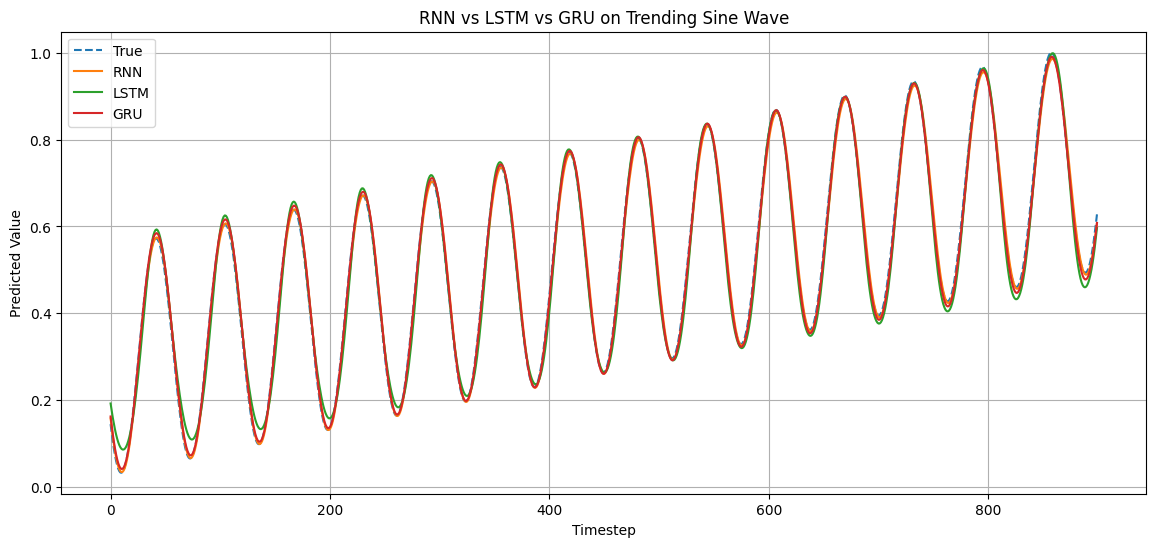

In [22]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Generate trending sine wave
np.random.seed(42)
t = np.linspace(0, 100, 1000)
sine = np.sin(t) + 0.02 * t
data = sine.reshape(-1, 1)

# Normalize
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

seq_len = 100
X, y = create_sequences(data, seq_len)
#X = torch.FloatTensor(X).unsqueeze(-1)  # shape: [batch, seq_len, input]
X = torch.FloatTensor(X)  # Shape: [samples, seq_len, 1]

y = torch.FloatTensor(y)

# Define RNN/LSTM/GRU classes
class SimpleRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(1, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1])

class SimpleLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1])

class SimpleGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(1, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1])

# Training function
def train(model, X, y, epochs=100, lr=0.01):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    losses = []
    for _ in range(epochs):
        optimizer.zero_grad()
        output = model(X).squeeze()
        loss = loss_fn(output, y.squeeze())
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

# Initialize and train models
rnn, lstm, gru = SimpleRNN(), SimpleLSTM(), SimpleGRU()
rnn_loss = train(rnn, X, y)
lstm_loss = train(lstm, X, y)
gru_loss = train(gru, X, y)

# Predict
rnn.eval(); lstm.eval(); gru.eval()
with torch.no_grad():
    rnn_pred = rnn(X).squeeze().numpy()
    lstm_pred = lstm(X).squeeze().numpy()
    gru_pred = gru(X).squeeze().numpy()
    y_true = y.squeeze().numpy()

# Plot predictions
plt.figure(figsize=(14, 6))
plt.plot(y_true, label='True', linestyle='--')
plt.plot(rnn_pred, label='RNN')
plt.plot(lstm_pred, label='LSTM')
plt.plot(gru_pred, label='GRU')
plt.title("RNN vs LSTM vs GRU on Trending Sine Wave")
plt.xlabel("Timestep")
plt.ylabel("Predicted Value")
plt.legend()
plt.grid(True)
plt.show()


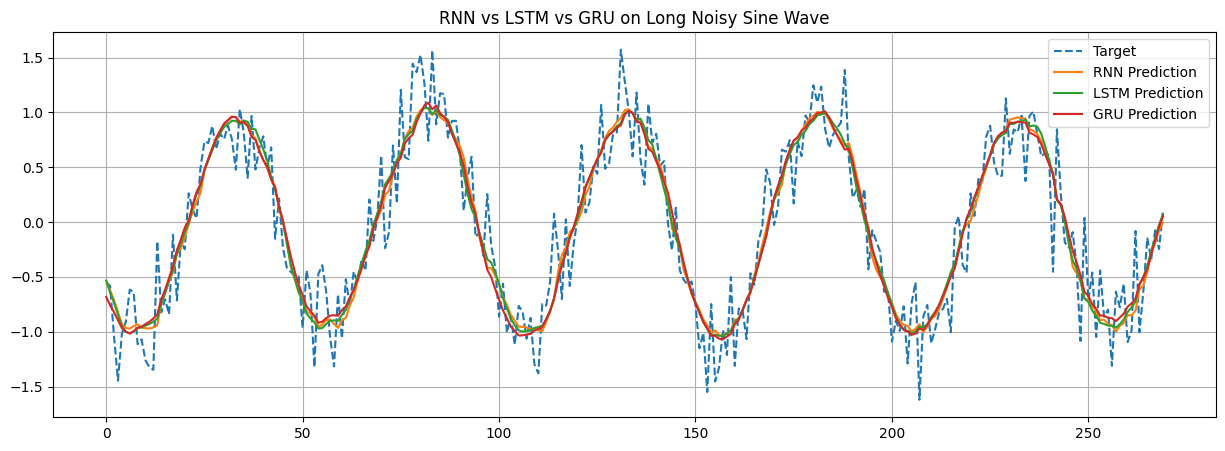

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Seed
np.random.seed(0)
torch.manual_seed(0)

# Generate a long, noisy sine wave
seq_length = 300
t = np.linspace(0, 12 * np.pi, seq_length)
data = np.sin(t) + 0.3 * np.random.randn(seq_length)

# Create input-output pairs
X, y = [], []
input_seq_len = 30
for i in range(len(data) - input_seq_len):
    X.append(data[i:i + input_seq_len])
    y.append(data[i + input_seq_len])
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # [N, seq_len, 1]
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # [N, 1]

# Define wrapper model
class RNNWrapper(nn.Module):
    def __init__(self, mode='RNN'):
        super().__init__()
        rnn_cls = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}[mode]
        self.rnn = rnn_cls(input_size=1, hidden_size=20, batch_first=True)
        self.fc = nn.Linear(20, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

# Train function
def train_model(mode):
    model = RNNWrapper(mode)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    for _ in range(100):
        model.train()
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
    model.eval()
    return model(X).detach().squeeze().numpy()

# Train all models
pred_rnn = train_model('RNN')
pred_lstm = train_model('LSTM')
pred_gru = train_model('GRU')
target = y.squeeze().numpy()

# Plot
plt.figure(figsize=(15, 5))
plt.plot(target, label='Target', linestyle='--')
plt.plot(pred_rnn, label='RNN Prediction')
plt.plot(pred_lstm, label='LSTM Prediction')
plt.plot(pred_gru, label='GRU Prediction')
plt.title("RNN vs LSTM vs GRU on Long Noisy Sine Wave")
plt.legend()
plt.grid(True)
plt.show()


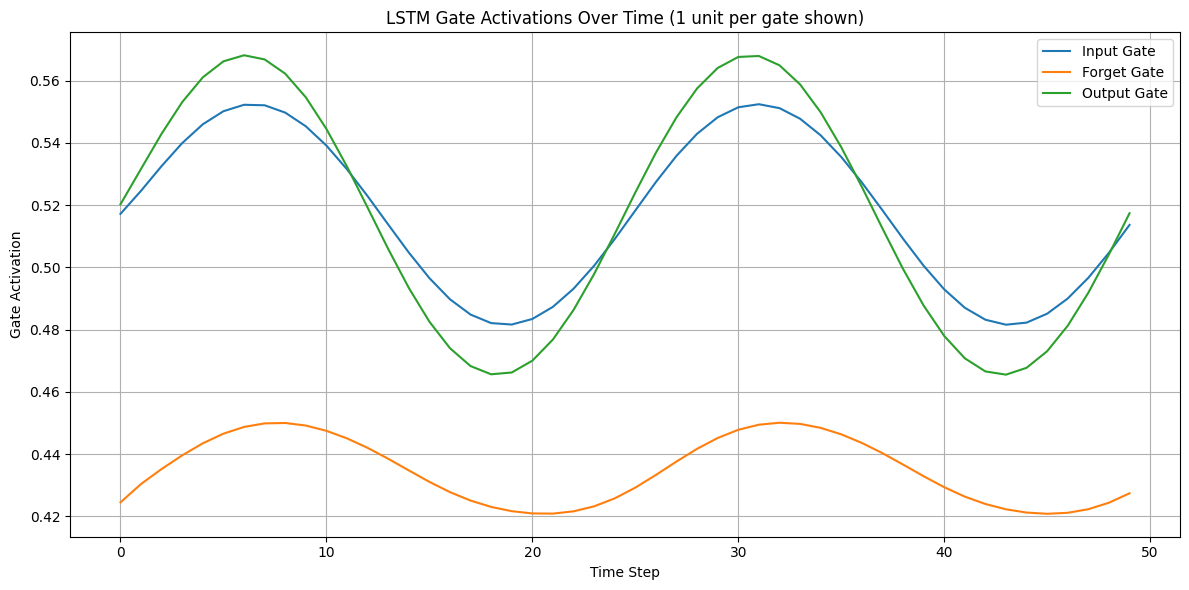

In [25]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Generate sine wave data
seq_len = 50
t = np.linspace(0, 4 * np.pi, seq_len)
data = np.sin(t)

# Prepare input tensor for LSTM
x = torch.tensor(data, dtype=torch.float32).view(seq_len, 1, 1)

# Custom LSTMCell wrapper to extract gates
class LSTMWithGateViz(nn.Module):
    def __init__(self, input_size=1, hidden_size=4):
        super().__init__()
        self.lstm_cell = nn.LSTMCell(input_size, hidden_size)
        self.hidden_size = hidden_size
        self.h_t = torch.zeros(1, hidden_size)
        self.c_t = torch.zeros(1, hidden_size)
        self.forget_gates, self.input_gates, self.output_gates = [], [], []

    def forward(self, x_seq):
        for x_t in x_seq:
            gates = torch.matmul(x_t, self.lstm_cell.weight_ih.t()) + \
                    torch.matmul(self.h_t, self.lstm_cell.weight_hh.t()) + \
                    self.lstm_cell.bias_ih + self.lstm_cell.bias_hh
    
            i_gate, f_gate, c_gate, o_gate = gates.chunk(4, dim=1)
            i_gate = torch.sigmoid(i_gate)
            f_gate = torch.sigmoid(f_gate)
            o_gate = torch.sigmoid(o_gate)
    
            self.input_gates.append(i_gate.mean().item())
            self.forget_gates.append(f_gate.mean().item())
            self.output_gates.append(o_gate.mean().item())
    
            self.h_t, self.c_t = self.lstm_cell(x_t, (self.h_t, self.c_t))


# Run model
model = LSTMWithGateViz()
model(x)

# Plot gates
plt.figure(figsize=(12, 6))
plt.plot(model.input_gates, label="Input Gate")
plt.plot(model.forget_gates, label="Forget Gate")
plt.plot(model.output_gates, label="Output Gate")
plt.xlabel("Time Step")
plt.ylabel("Gate Activation")
plt.title("LSTM Gate Activations Over Time (1 unit per gate shown)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Need to know